# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Claire McGinn

**Date:** 09/09/2026

<class 'pandas.Series'>
RangeIndex: 28221 entries, 0 to 28220
Series name: Foreign Gift Amount
Non-Null Count  Dtype
--------------  -----
28221 non-null  int64
dtypes: int64(1)
memory usage: 220.6 KB


/workspaces/A02-eda-and-visualization/venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Giftor Name
Saudi Arabian Cultural Mission    480
Human Frontier Science Program    287
Anonymous                         262
Qatar Foundation                  261
Novartis Pharmaceuticals Corp     251
Royal Embassy of Saudi Arabia     210
Acerta Pharma B.V.                210
Contracting Party                 143
Gwangju Institute of S&T          141
WSB Universities                  140
Name: count, dtype: int64

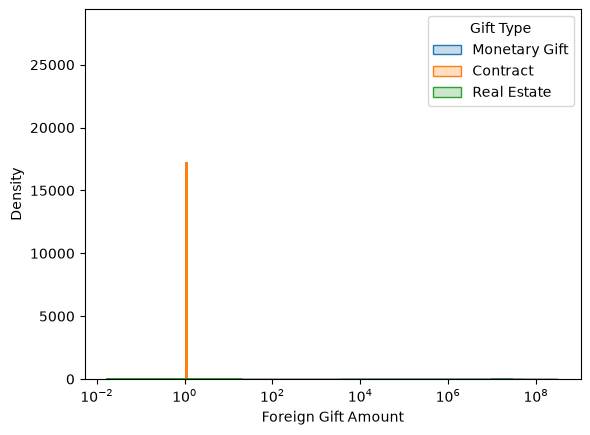

In [2]:
#1
# My Q1 Phase 1 solutions are uploaded on GitHub as A2 Q1 Equation Derivations

#2

#2.1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('./data/ForeignGifts_edu.csv')
#df_foreign_gifts = df['Foreign Gifts']
#2.2
value1 = "Foreign Gift Amount"
df_foreign_gift_amount = df["Foreign Gift Amount"]
df["Foreign Gift Amount"].hist(grid=False)
df["Foreign Gift Amount"].info()
#The variable Foreign Gift Amount occrs 28221 times. It is an interger value.

#2.3
value2 = "Gift Type"
df_gift_type = df["Gift Type"]
df["Gift Type"].hist(grid=False)
df["Gift Type"].value_counts(normalize=True)
#61% of 0.61 of the gift are Contracts, 38% or 0.38 are Monetary Gifts, and 0.04% or 0.0004 are Real Estate

#2.4
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#df[df['Foreign Gift Amount'] <= 0]#.counts()
#df['Foreign Gift Amount'].np.log(df['Foreign Gift Amount'])

df_new = df[df["Foreign Gift Amount"] > 0].copy()
df_new["Foreign Gift Amount"] = np.log(df_new["Foreign Gift Amount"])
sns.kdeplot(data=np.log(df['Foreign Gift Amount']))

sns.kdeplot(
    data=df,
    log_scale=True,
    x="Foreign Gift Amount",
    hue="Gift Type",
    fill=True)
#I noticed that the Contracts curve closesly resembled the curve of the overall Foregin Gift Amount

#2.5
df.value_counts("Country of Giftor").head(15)
#df.loc[df['Country of Giftor'].map(df['Country of Giftor'].value_counts()).sort_values(ascending=False).index].head(15)
df.sort_values(by='Country of Giftor', ascending=False).head(15)

#2.6
df.value_counts('Giftor Name').head(10)
#Some of the giftors who provide the most money include Saudi Arabian Cultural Mission, Human Frontier Science Program, and an Anonymous giftor

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** (http://f826c0f53ea44a8857fb79146b02b577a51722e8)
- **AI tool and model used:** I used Google Gemini

### *Prompts used

1. I am going to upload question 1 and then my answers -- please revise them
2. Given this question and the following code, clean any errors

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Question 1: Show that $m(a + bX) = a + b \cdot m(X)$Corrections to your draft:In line 1 of your draft, you defined $m(X)$ using $Y_i$ instead of $X_i$.In line 4, an extraneous index $i$ appeared in front of the sum.Instead of setting the expression equal to the RHS (right-hand side) immediately, start with the LHS (left-hand side) definition and expand it sequentially.Revised Solution:Applying the definition of the sample mean $m(\cdot)$:$$m(a + bX) = \frac{1}{N} \sum_{i=1}^{N} (a + b x_i)$$Split the summation across addition:$$m(a + bX) = \frac{1}{N} \left( \sum_{i=1}^{N} a + \sum_{i=1}^{N} b x_i \right)$$Since $\sum_{i=1}^{N} a = N \cdot a$ and $b$ is a constant:$$m(a + bX) = \frac{1}{N} \left( N \cdot a + b \sum_{i=1}^{N} x_i \right)$$Distribute $\frac{1}{N}$:$$m(a + bX) = \frac{N \cdot a}{N} + b \cdot \left( \frac{1}{N} \sum_{i=1}^{N} x_i \right) = a + b \cdot m(X)$$Question 2: Show that $\operatorname{cov}(X, a + bY) = b \cdot \operatorname{cov}(X, Y)$Corrections to your draft:Apply $m(a + bY) = a + b \cdot m(Y)$ explicitly from Part 1 right at the start.Keep notation consistent (avoid switching between uppercase $Y$ and lowercase $y$).Revised Solution:Applying the definition of covariance:$$\operatorname{cov}(X, a + bY) = \frac{1}{N} \sum_{i=1}^{N} (x_i - m(X))\Big((a + b y_i) - m(a + bY)\Big)$$From Part 1, substitute $m(a + bY) = a + b \cdot m(Y)$:$$\operatorname{cov}(X, a + bY) = \frac{1}{N} \sum_{i=1}^{N} (x_i - m(X))\Big(a + b y_i - (a + b \cdot m(Y))\Big)$$Simplify the second factor: $a + b y_i - a - b \cdot m(Y) = b(y_i - m(Y))$:$$\operatorname{cov}(X, a + bY) = \frac{1}{N} \sum_{i=1}^{N} (x_i - m(X)) \cdot b(y_i - m(Y))$$Factor out the constant $b$:$$\operatorname{cov}(X, a + bY) = b \cdot \left( \frac{1}{N} \sum_{i=1}^{N} (x_i - m(X))(y_i - m(Y)) \right) = b \cdot \operatorname{cov}(X, Y)$$Question 3: Show that $\operatorname{cov}(a + bX, a + bX) = b^2 \operatorname{cov}(X, X)$, and in particular $\operatorname{cov}(X, X) = s^2$Corrections to your draft:In line 1, your work accidentally wrote $b^2 \operatorname{cov}(X, Y)$ instead of $b^2 \operatorname{cov}(X, X)$.Separate this question clearly into Part A (the $b^2$ identity) and Part B (showing $\operatorname{cov}(X,X) = s^2$).Revised Solution:Part A: Show that $\operatorname{cov}(a + bX, a + bX) = b^2 \operatorname{cov}(X, X)$$$\operatorname{cov}(a + bX, a + bX) = \frac{1}{N} \sum_{i=1}^{N} \Big((a + b x_i) - m(a + bX)\Big)\Big((a + b x_i) - m(a + bX)\Big)$$Substitute $m(a + bX) = a + b \cdot m(X)$:$$\operatorname{cov}(a + bX, a + bX) = \frac{1}{N} \sum_{i=1}^{N} \Big(b(x_i - m(X))\Big)\Big(b(x_i - m(X))\Big)$$Factor out $b \cdot b = b^2$:$$\operatorname{cov}(a + bX, a + bX) = b^2 \cdot \left( \frac{1}{N} \sum_{i=1}^{N} (x_i - m(X))(x_i - m(X)) \right) = b^2 \cdot \operatorname{cov}(X, X)$$Part B: Show that $\operatorname{cov}(X, X) = s^2$$$\operatorname{cov}(X, X) = \frac{1}{N} \sum_{i=1}^{N} (x_i - m(X))(x_i - m(X)) = \frac{1}{N} \sum_{i=1}^{N} (x_i - m(X))^2 = s^2$$Question 4: Is it always true that $m(g(X)) = g(m(X))$ for a non-decreasing transformation $g()$?Corrections to your draft:Your reasoning is spot on! Adding a simple counterexample will make your answer 100% complete and airtight.Revised Solution:No, it is not always true.The sample mean is only linear, so $m(g(X)) = g(m(X))$ generally holds only when $g(\cdot)$ is a linear transformation. Even if $g(\cdot)$ is non-decreasing (monotone), non-linear convex or concave functions break this equality (e.g., Jensen's Inequality).Counterexample:Let $X = \{0, 4\}$ and $g(x) = x^2$ (which is strictly increasing/non-decreasing for $x \ge 0$).Calculate $g(m(X))$:$m(X) = \frac{0 + 4}{2} = 2$$g(m(X)) = g(2) = 2^2 = 4$Calculate $m(g(X))$:$g(X) = \{0^2, 4^2\} = \{0, 16\}$$m(g(X)) = \frac{0 + 16}{2} = 8$Since $8 \neq 4$, $m(g(X)) \neq g(m(X))$ in general.
2. Here is a review and polished revision for Question 2, including fixes for pandas syntax errors in your code and additions for parts 2.5 and 2.6.

2.1 Load Dataset
Python
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('./data/ForeignGifts_edu.csv')
2.2 Foreign Gift Amount Analysis
Code Revision:
Calling .info() directly on a Series object (df["Foreign Gift Amount"].info()) will raise an AttributeError in pandas. Use .info() on the DataFrame or .describe() / .dtype on the Series.

Python
# Histogram
plt.figure(figsize=(8, 4))
df["Foreign Gift Amount"].hist(grid=False, bins=30)
plt.title("Histogram of Foreign Gift Amount")
plt.xlabel("Amount ($)")
plt.ylabel("Frequency")
plt.show()

# Summary statistics & data type
print(df["Foreign Gift Amount"].describe())
print(f"Data type: {df['Foreign Gift Amount'].dtype}")
Findings / Written Response:
The variable Foreign Gift Amount contains 28,221 non-null observations. It is heavily right-skewed, with a vast majority of gift amounts clustered near lower dollar values and a few extreme outliers extending into very large values (making a standard histogram difficult to read without transformation).

2.3 Gift Type Analysis
Code Revision:
hist() works best on numerical variables. For categorical variables like Gift Type, use value_counts() or a Seaborn countplot().

Python
# Proportions
gift_type_props = df["Gift Type"].value_counts(normalize=True)
print(gift_type_props)

# Visualizing distributions
sns.countplot(data=df, x="Gift Type")
plt.title("Distribution of Gift Types")
plt.show()
Findings / Written Response:
Contracts: ~61.2% (0.612)

Monetary Gifts: ~38.4% (0.384)

Real Estate: ~0.4% (0.004)

Contracts make up the majority of transfers, followed by monetary gifts, while real estate transfers represent less than 1% of all entries.

2.4 KDE Plot of Log(Foreign Gift Amount)
Code Revision:
In your draft code, sns.kdeplot(data=np.log(df['Foreign Gift Amount'])) will fail if there are non-positive values (e.g., 0 or negative values) or missing values, causing log(0) = -inf. Using Seaborn's built-in log_scale=True handles log scaling cleanly.

Python
# 1. Overall log KDE plot
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x="Foreign Gift Amount", log_scale=True, fill=True)
plt.title("KDE Plot of Log(Foreign Gift Amount)")
plt.xlabel("Foreign Gift Amount (Log Scale)")
plt.show()

# 2. Log KDE plot conditional on Gift Type
plt.figure(figsize=(8, 4))
sns.kdeplot(
    data=df,
    x="Foreign Gift Amount",
    hue="Gift Type",
    log_scale=True,
    fill=True,
    common_norm=False
)
plt.title("KDE Plot of Log(Foreign Gift Amount) by Gift Type")
plt.xlabel("Foreign Gift Amount (Log Scale)")
plt.show()
Findings / Written Response:
The overall log distribution of gift amounts is roughly bimodal/multimodal, indicating distinct categories of transaction sizes. When conditioning on Gift Type, Contracts and Monetary Gifts exhibit similar overall spread, but Contracts tend to dominate higher-value transactions. Real estate distributions have a much smaller sample size and tend to skew toward larger monetary values.

2.5 Top 15 Countries by Count and Total Amount
Here is the code required for part 5 using .groupby():

Python
# Top 15 countries by number of gifts (count)
top15_country_count = (
    df.groupby("Country")["Foreign Gift Amount"]
    .count()
    .sort_values(ascending=False)
    .head(15)
)
print("Top 15 Countries by Number of Gifts:\n", top15_country_count)

# Top 15 countries by total gift amount (sum)
top15_country_amount = (
    df.groupby("Country")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)
print("\nTop 15 Countries by Total Amount Given:\n", top15_country_amount)
2.6 Giftors Providing the Most Money Overall
Here is the code required for part 6 using .groupby():

Python
# Replace 'Giftor' with the exact column name in your dataset (e.g., 'Giftor Name', 'Foreign Entity Name')
giftor_col = "Giftor"  # Adjust column name as necessary

top_giftors = (
    df.groupby(giftor_col)["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print("Top Giftors by Total Amount Given:\n", top_giftors)
(Note: Double check the exact column name for the giftor in your CSV file, such as "Foreign Entity Name", "Giftor", or "Donor Name", and update giftor_col accordingly.)

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 Corrections to equation derivations 1.1-3| Reject | I chose to leave my derivations as be because they were all small errors with notation (such as swtiching from upper to lowercase Y) that did not make the solution itself incorrect |
| 2 Write counterexample for 1.4 | Accept | I chose to add reasoning to my statement to prove that the m(g(x)) does not always equal g(m(x)) |
| 3 Use .info() of the DataFrame for 2.2 | Accept | I swapped my use of .info for .describe() so I would not raise an attribute error|
| 4 Use .countplot() | Reject | I kept my histogram plot because they were the focus of this assignment|
| 5 KDE plot revisions | Accept | I revised my KDE plots so that log_scale=True was present|
| 6 Use .groupby() | Accept | I used .groupby() to allow me to find the sum of of the top 15 countries total gift amount |
| 7 Use .sum() | Accept | I used .sum() to revise my asnwer for #2.6 and giving me a truer sense of who the top giftors are |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: Foreign Gift Amount, dtype: int64
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64

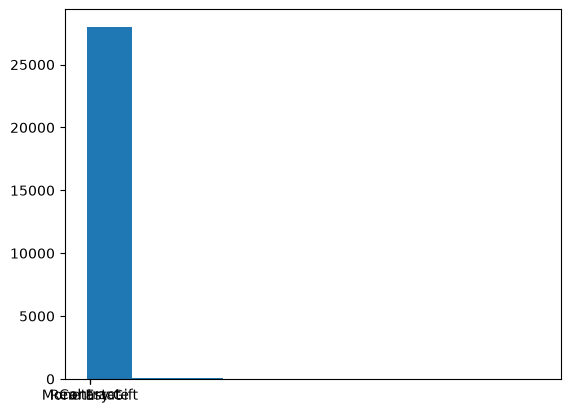

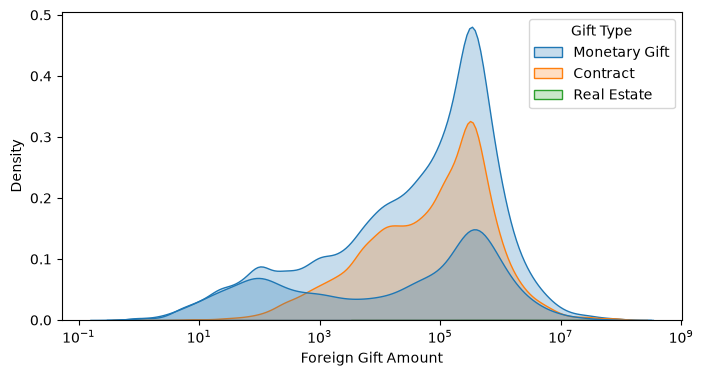

In [26]:
# My corrected calculations for #1 are uploaded in my GitHub repo as A2 Q1 Phase 2 Revised Answers

#2.1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('./data/ForeignGifts_edu.csv')
#df_foreign_gifts = df['Foreign Gifts']
#2.2
value1 = "Foreign Gift Amount"
df_foreign_gift_amount = df["Foreign Gift Amount"]
df["Foreign Gift Amount"].hist(grid=False)
df["Foreign Gift Amount"].describe()
#The variable Foreign Gift Amount occrs 28221 times. It is an interger value.

#2.3
value2 = "Gift Type"
df_gift_type = df["Gift Type"]
df["Gift Type"].hist(grid=False)
df["Gift Type"].value_counts(normalize=True)
#61% of 0.61 of the gift are Contracts, 38% or 0.38 are Monetary Gifts, and 0.04% or 0.0004 are Real Estate

#2.4
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#df[df['Foreign Gift Amount'] <= 0]#.counts()
#df['Foreign Gift Amount'].np.log(df['Foreign Gift Amount'])

df_new = df[df["Foreign Gift Amount"] > 0].copy()
#df_new["Foreign Gift Amount"] = np.log(df_new["Foreign Gift Amount"])
#sns.kdeplot(data=np.log(df['Foreign Gift Amount']),log_scale=True, fill=True)
plt.figure(figsize=(8, 4))
sns.kdeplot(
    data=df_new, 
    x="Foreign Gift Amount", 
    log_scale=True, 
    fill=True)

sns.kdeplot(
    data=df,
    log_scale=True,
    x="Foreign Gift Amount",
    hue="Gift Type",
    fill=True)
#I noticed that the Contracts curve closesly resembled the curve of the overall Foregin Gift Amount

#2.5
top15_country_count = (
    df.groupby("Country of Giftor")["Foreign Gift Amount"]
    .count()
    .sort_values(ascending=False)
    .head(15)
)
print(top15_country_count)
top15_country_amount = (
    df.groupby("Country of Giftor")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)
print(top15_country_amount)

#2.6
top_giftors = (
    df.groupby('Giftor Name')["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print(top_giftors)
#Some of the giftors who provide the most money include The Qatar Foundation, Anonymous, and Saudi Arabian Cultural Mission

### *Reflection on AI assistance
In your own words without generative AI.

AI was helpful in catching small bugs and telling me when to expand on things. For the equations, it was helpful in telling me to give an example. For errors that were not caught while running, AI is incredible helpful to make sure you do not get stuck in loops. I made some errors by not creating values and just working with the DataFrame, so AI caught those errors and made my data print much more cleanly. AI can also catch extraneous errors that are not always necessary to change. An issue that I often run into with when AI is revising your code is that it will often give solutions that are without of the scope of this class and thus can overcomplicate my code so that I could not replicate it myself at this time. I think it is important to truly understand the data after getting AI assistance so that you do not become solely reliant on it.